In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from pathlib import Path

DATA_DIR = Path("../data/raw")

csv_files = sorted(DATA_DIR.glob("*.csv"))

print("Number of CSV files:", len(csv_files))

for file in csv_files:
    print(file.name)

Number of CSV files: 8
Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
Friday-WorkingHours-Morning.pcap_ISCX.csv
Monday-WorkingHours.pcap_ISCX.csv
Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
Tuesday-WorkingHours.pcap_ISCX.csv
Wednesday-workingHours.pcap_ISCX.csv


In [3]:
file = csv_files[0]

df = pd.read_csv(file)

print("Shape:", df.shape)

Shape: (225745, 79)


In [4]:
print("Number of columns:", len(df.columns))

for i, column in enumerate(df.columns):
    print(i, repr(column))

Number of columns: 79
0 ' Destination Port'
1 ' Flow Duration'
2 ' Total Fwd Packets'
3 ' Total Backward Packets'
4 'Total Length of Fwd Packets'
5 ' Total Length of Bwd Packets'
6 ' Fwd Packet Length Max'
7 ' Fwd Packet Length Min'
8 ' Fwd Packet Length Mean'
9 ' Fwd Packet Length Std'
10 'Bwd Packet Length Max'
11 ' Bwd Packet Length Min'
12 ' Bwd Packet Length Mean'
13 ' Bwd Packet Length Std'
14 'Flow Bytes/s'
15 ' Flow Packets/s'
16 ' Flow IAT Mean'
17 ' Flow IAT Std'
18 ' Flow IAT Max'
19 ' Flow IAT Min'
20 'Fwd IAT Total'
21 ' Fwd IAT Mean'
22 ' Fwd IAT Std'
23 ' Fwd IAT Max'
24 ' Fwd IAT Min'
25 'Bwd IAT Total'
26 ' Bwd IAT Mean'
27 ' Bwd IAT Std'
28 ' Bwd IAT Max'
29 ' Bwd IAT Min'
30 'Fwd PSH Flags'
31 ' Bwd PSH Flags'
32 ' Fwd URG Flags'
33 ' Bwd URG Flags'
34 ' Fwd Header Length'
35 ' Bwd Header Length'
36 'Fwd Packets/s'
37 ' Bwd Packets/s'
38 ' Min Packet Length'
39 ' Max Packet Length'
40 ' Packet Length Mean'
41 ' Packet Length Std'
42 ' Packet Length Variance'
43 'FIN 

In [5]:
df.columns = df.columns.str.strip()

In [6]:
print(df.columns.tolist())

['Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Min Packet Length', 'Max Packet Length', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count', 'SYN Flag Count', 'RST Flag Count', 'PSH Flag Count', 'ACK Flag Count', 'URG Flag Count', 'CWE Flag Count', 'ECE Flag Count

In [7]:
print(df["Label"].value_counts())

Label
DDoS      128027
BENIGN     97718
Name: count, dtype: int64


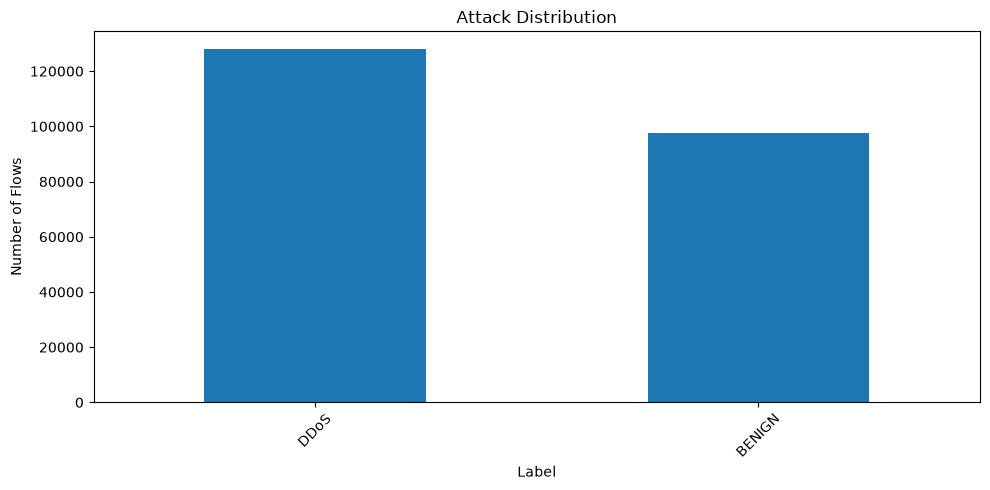

In [8]:
label_counts = df["Label"].value_counts()

plt.figure(figsize=(10, 5))
label_counts.plot(kind="bar")
plt.title("Attack Distribution")
plt.xlabel("Label")
plt.ylabel("Number of Flows")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [9]:
missing = df.isnull().sum()

missing = missing[missing > 0]

print(missing)

Flow Bytes/s    4
dtype: int64


In [10]:
numeric_df = df.select_dtypes(include=np.number)

inf_count = np.isinf(numeric_df).sum().sum()

print("Infinite values:", inf_count)

Infinite values: 64


In [11]:
print(df.dtypes.value_counts())

int64      54
float64    24
str         1
Name: count, dtype: int64


In [12]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 225745 entries, 0 to 225744
Data columns (total 79 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Destination Port             225745 non-null  int64  
 1   Flow Duration                225745 non-null  int64  
 2   Total Fwd Packets            225745 non-null  int64  
 3   Total Backward Packets       225745 non-null  int64  
 4   Total Length of Fwd Packets  225745 non-null  int64  
 5   Total Length of Bwd Packets  225745 non-null  int64  
 6   Fwd Packet Length Max        225745 non-null  int64  
 7   Fwd Packet Length Min        225745 non-null  int64  
 8   Fwd Packet Length Mean       225745 non-null  float64
 9   Fwd Packet Length Std        225745 non-null  float64
 10  Bwd Packet Length Max        225745 non-null  int64  
 11  Bwd Packet Length Min        225745 non-null  int64  
 12  Bwd Packet Length Mean       225745 non-null  float64
 13  Bwd Packet

In [13]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 2633


In [14]:
print(df.describe().T)

c:\Users\arvin\Desktop\projects\adversarial-ids\.venv\Lib\site-packages\pandas\core\nanops.py:1028: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
c:\Users\arvin\Desktop\projects\adversarial-ids\.venv\Lib\site-packages\pandas\core\nanops.py:1028: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


                                count          mean           std  min  \
Destination Port             225745.0  8.879619e+03  1.975465e+04  0.0   
Flow Duration                225745.0  1.624165e+07  3.152437e+07 -1.0   
Total Fwd Packets            225745.0  4.874916e+00  1.542287e+01  1.0   
Total Backward Packets       225745.0  4.572775e+00  2.175536e+01  0.0   
Total Length of Fwd Packets  225745.0  9.394633e+02  3.249403e+03  0.0   
...                               ...           ...           ...  ...   
Active Min                   225745.0  1.776201e+05  7.842602e+05  0.0   
Idle Mean                    225745.0  1.032214e+07  2.185303e+07  0.0   
Idle Std                     225745.0  3.611943e+06  1.275689e+07  0.0   
Idle Max                     225745.0  1.287813e+07  2.692126e+07  0.0   
Idle Min                     225745.0  7.755355e+06  1.983109e+07  0.0   

                                 25%        50%        75%          max  
Destination Port                80.0 

In [15]:
import sys

sys.path.append("../")

from src.preprocessing.dataset_loader import load_csv_files

In [16]:
df = load_csv_files("../data/raw")

print("Final shape:", df.shape)

Loading: Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
Loading: Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
Loading: Friday-WorkingHours-Morning.pcap_ISCX.csv
Loading: Monday-WorkingHours.pcap_ISCX.csv
Loading: Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
Loading: Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
Loading: Tuesday-WorkingHours.pcap_ISCX.csv
Loading: Wednesday-workingHours.pcap_ISCX.csv
Final shape: (2830743, 79)


In [17]:
df["Label"] = df["Label"].astype(str).str.strip()

df["target"] = (
    df["Label"]
    .str.upper()
    .ne("BENIGN")
    .astype(int)
)

In [18]:
print(df[["Label", "target"]].drop_duplicates())

                              Label  target
0                            BENIGN       0
18883                          DDoS       1
227208                     PortScan       1
536284                          Bot       1
1299546                Infiltration       1
1534402    Web Attack � Brute Force       1
1593899            Web Attack � XSS       1
1612058  Web Attack � Sql Injection       1
1703478                 FTP-Patator       1
1854120                 SSH-Patator       1
2144598               DoS slowloris       1
2207315            DoS Slowhttptest       1
2212900                    DoS Hulk       1
2469073               DoS GoldenEye       1
2735170                  Heartbleed       1


In [20]:
df = df.replace([np.inf, -np.inf], np.nan)

print("Infinite values after replacement:",
      np.isinf(df.select_dtypes(include=np.number)).sum().sum())

Infinite values after replacement: 0


In [21]:
missing = df.isnull().sum()
missing = missing[missing > 0]

print(missing)

Flow Bytes/s      2867
Flow Packets/s    2867
dtype: int64


In [22]:
print("Total missing values:", df.isnull().sum().sum())

Total missing values: 5734


In [23]:
df = df.dropna()

In [24]:
print("Shape after removing missing values:", df.shape)

Shape after removing missing values: (2827876, 80)


In [25]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 307078


In [26]:
before = len(df)

df = df.drop_duplicates()

after = len(df)

print("Rows before:", before)
print("Rows after:", after)
print("Duplicates removed:", before - after)

Rows before: 2827876
Rows after: 2520798
Duplicates removed: 307078


In [27]:
print("Final shape:", df.shape)

Final shape: (2520798, 80)


In [28]:
print(df["target"].value_counts())

target
0    2095057
1     425741
Name: count, dtype: int64


In [29]:
print(df["target"].value_counts(normalize=True) * 100)

target
0    83.110864
1    16.889136
Name: proportion, dtype: float64


In [30]:
print(df["Label"].value_counts())

Label
BENIGN                        2095057
DoS Hulk                       172846
DDoS                           128014
PortScan                        90694
DoS GoldenEye                   10286
FTP-Patator                      5931
DoS slowloris                    5385
DoS Slowhttptest                 5228
SSH-Patator                      3219
Bot                              1948
Web Attack � Brute Force         1470
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64


In [31]:
attack_df = df[df["target"] == 1]

print("Number of attack flows:", len(attack_df))

print("\nAttack distribution:")
print(attack_df["Label"].value_counts())

Number of attack flows: 425741

Attack distribution:
Label
DoS Hulk                      172846
DDoS                          128014
PortScan                       90694
DoS GoldenEye                  10286
FTP-Patator                     5931
DoS slowloris                   5385
DoS Slowhttptest                5228
SSH-Patator                     3219
Bot                             1948
Web Attack � Brute Force        1470
Web Attack � XSS                 652
Infiltration                      36
Web Attack � Sql Injection        21
Heartbleed                        11
Name: count, dtype: int64


In [32]:
TARGET_COLUMN = "target"
LABEL_COLUMN = "Label"

In [33]:
X = df.drop(columns=[TARGET_COLUMN, LABEL_COLUMN])
y = df[TARGET_COLUMN]

In [34]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (2520798, 78)
y shape: (2520798,)


In [35]:
print(X.dtypes.value_counts())

int64      54
float64    24
Name: count, dtype: int64


In [36]:
non_numeric = X.select_dtypes(exclude=np.number).columns

print("Non-numeric features:")
print(non_numeric.tolist())

Non-numeric features:
[]


In [37]:
constant_features = [
    column
    for column in X.columns
    if X[column].nunique(dropna=False) <= 1
]

print("Constant features:", constant_features)

Constant features: ['Bwd PSH Flags', 'Bwd URG Flags', 'Fwd Avg Bytes/Bulk', 'Fwd Avg Packets/Bulk', 'Fwd Avg Bulk Rate', 'Bwd Avg Bytes/Bulk', 'Bwd Avg Packets/Bulk', 'Bwd Avg Bulk Rate']


In [38]:
X = X.drop(columns=constant_features)

print("Features after removing constants:", X.shape[1])

Features after removing constants: 70


In [39]:
numeric_summary = X.describe().T

print(
    numeric_summary[
        ["min", "max", "mean", "std"]
    ].sort_values("max", ascending=False).head(15)
)

                                     min           max          mean  \
Flow Bytes/s                -261000000.0  2.071000e+09  1.410707e+06   
Total Length of Bwd Packets          0.0  6.554530e+08  1.814440e+04   
Subflow Bwd Bytes                    0.0  6.554530e+08  1.814402e+04   
Fwd IAT Mean                         0.0  1.200000e+08  2.919257e+06   
Flow IAT Max                       -13.0  1.200000e+08  1.029948e+07   
Flow IAT Mean                      -13.0  1.200000e+08  1.446142e+06   
Bwd IAT Mean                         0.0  1.200000e+08  2.027734e+06   
Bwd IAT Total                        0.0  1.200000e+08  1.111025e+07   
Bwd IAT Max                          0.0  1.200000e+08  5.260619e+06   
Bwd IAT Min                          0.0  1.200000e+08  1.086111e+06   
Idle Min                             0.0  1.200000e+08  8.892671e+06   
Fwd IAT Total                        0.0  1.200000e+08  1.625184e+07   
Fwd IAT Min                        -12.0  1.200000e+08  1.135671

In [40]:
from sklearn.model_selection import train_test_split

In [41]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

In [42]:
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

In [43]:
print("Training:", X_train.shape)
print("Validation:", X_val.shape)
print("Testing:", X_test.shape)

Training: (1764558, 70)
Validation: (378120, 70)
Testing: (378120, 70)


In [44]:
print("\nTrain labels:")
print(y_train.value_counts(normalize=True))

print("\nValidation labels:")
print(y_val.value_counts(normalize=True))

print("\nTest labels:")
print(y_test.value_counts(normalize=True))


Train labels:
target
0    0.831108
1    0.168892
Name: proportion, dtype: float64

Validation labels:
target
0    0.831109
1    0.168891
Name: proportion, dtype: float64

Test labels:
target
0    0.831109
1    0.168891
Name: proportion, dtype: float64


In [45]:
from sklearn.preprocessing import StandardScaler

In [46]:
scaler = StandardScaler()

In [47]:
X_train_scaled = scaler.fit_transform(X_train)

In [48]:
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

In [49]:
X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=X_train.columns,
    index=X_train.index
)

X_val_scaled = pd.DataFrame(
    X_val_scaled,
    columns=X_val.columns,
    index=X_val.index
)

X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=X_test.columns,
    index=X_test.index
)

In [50]:
print(X_train_scaled.head())

         Destination Port  Flow Duration  Total Fwd Packets  \
187432          -0.452789      -0.338783          -0.006800   
2822338          1.981000      -0.468185          -0.010521   
2630562          2.765717      -0.470969          -0.010521   
1048512         -0.454209      -0.470087          -0.010521   
586564           2.290353      -0.470967          -0.011761   

         Total Backward Packets  Total Length of Fwd Packets  \
187432                -0.011024                    -0.089434   
2822338               -0.011024                    -0.094095   
2630562               -0.011024                    -0.092231   
1048512               -0.009162                    -0.083841   
586564                -0.009162                    -0.093163   

         Total Length of Bwd Packets  Fwd Packet Length Max  \
187432                     -0.007722              -0.297713   
2822338                    -0.007722              -0.305651   
2630562                    -0.007722           

In [51]:
print("Training means:")
print(X_train_scaled.mean().abs().max())

print("\nTraining standard deviations:")
print(X_train_scaled.std().mean())

Training means:
1.0118408045629442e-16

Training standard deviations:
1.0000002833571988


In [52]:
from pathlib import Path

SPLIT_DIR = Path("../data/splits")
SPLIT_DIR.mkdir(parents=True, exist_ok=True)

In [53]:
X_train_scaled.to_csv(SPLIT_DIR / "X_train.csv", index=False)
X_val_scaled.to_csv(SPLIT_DIR / "X_val.csv", index=False)
X_test_scaled.to_csv(SPLIT_DIR / "X_test.csv", index=False)

y_train.to_csv(SPLIT_DIR / "y_train.csv", index=False)
y_val.to_csv(SPLIT_DIR / "y_val.csv", index=False)
y_test.to_csv(SPLIT_DIR / "y_test.csv", index=False)